# L-BFGS-B Multi-Season Fit (21-dim, age-dependent gamma)

First production fit. 4 seasons parallel via joblib, tracked with mlflow.
- Vector: 21-dim (beta(4) + phi(14) + gamma_child/adult/elder(3))
- Seasonality: cosine fixed (amp=0.7, peak=105)
- Method: L-BFGS-B, maxiter=500
- Seasons: 2017-2018, 2018-2019, 2019-2020, 2022-2023


In [1]:
# Cell 1 — Setup + BLAS safety
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

import time, json, warnings
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed

import mlflow
mlflow.set_tracking_uri("sqlite:///" + str(Path("../outputs/mlruns/mlflow.db").resolve()))
mlflow.set_experiment("hira_calibration_first_fit")

from kt_data import HIRA_AGE_GROUPS, SUDOGWON_SIDO_CODES
from kt_epimodel_hira.calibration.hira_target import (
    HIRA_GROUP_TO_NIMS_WEIGHTED, load_hira_target_by_age,
    simulation_to_hira_by_age, poisson_log_likelihood,
)
from kt_epimodel_hira.calibration.simple_model import (
    build_aggregated_inputs, estimate_initial_infected_from_hira, simulate_aggregated,
)
from kt_epimodel_hira.calibration.loss import make_loss_function_by_age
from kt_epimodel_hira.calibration.param_vector import (
    get_bounds_vector, get_param_names, initial_guess, vector_to_params,
    params_to_vector, ParameterBounds, N_VECTOR,
)
from kt_epimodel_hira.calibration.optimizer import (
    optimize_calibration_by_age, CalibrationResult, save_result,
)
from kt_epimodel_hira.model.parameters import (
    CalibrationParameters, DiseaseParameters, ModelParameters, GAMMA_AGE_GROUPS,
)

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150,
                     "axes.unicode_minus": False, "font.family": "DejaVu Sans"})

OUTDIR = Path("../outputs/calibration"); OUTDIR.mkdir(parents=True, exist_ok=True)
SEASONS = ["2017-2018", "2018-2019", "2019-2020", "2022-2023"]
MAX_ITER = 500
BETA_INIT = 0.06
NAMES = get_param_names()

print(f"L-BFGS-B x {len(SEASONS)} seasons, maxiter={MAX_ITER}, {N_VECTOR}-dim")
print(f"BLAS threads: OMP={os.environ.get('OMP_NUM_THREADS')}")


2026/05/28 08:54:16 INFO mlflow.tracking.fluent: Experiment with name 'hira_calibration_first_fit' does not exist. Creating a new experiment.


L-BFGS-B x 4 seasons, maxiter=500, 21-dim
BLAS threads: OMP=1


In [2]:
# Cell 2 — Initial vector + custom bounds
cal_init = CalibrationParameters(
    beta_h=BETA_INIT, beta_w=BETA_INIT, beta_s=BETA_INIT, beta_o=BETA_INIT,
)
init_vec = params_to_vector(cal_init)
print(f"Initial vector ({len(init_vec)}-dim):")
for n, v in zip(NAMES, init_vec):
    print(f"  {n:>18}: {v:.4f}")

custom_bounds = ParameterBounds(
    beta_h=(0.01, 0.30), beta_w=(0.01, 0.30),
    beta_s=(0.01, 0.30), beta_o=(0.01, 0.30),
    phi=(0.1, 5.0),
    gamma_child=(0.10, 0.60), gamma_adult=(0.05, 0.40), gamma_elder=(0.10, 0.50),
)
bounds_vec = get_bounds_vector(custom_bounds)
print(f"\nBounds ({len(bounds_vec)} entries):")
for n, (lo, hi) in zip(NAMES, bounds_vec):
    print(f"  {n:>18}: [{lo:.3f}, {hi:.3f}]")


Initial vector (21-dim):
              beta_h: 0.0600
              beta_w: 0.0600
              beta_s: 0.0600
              beta_o: 0.0600
               phi_0: 1.0000
               phi_1: 1.0000
               phi_2: 1.0000
               phi_3: 1.0000
               phi_4: 1.0000
               phi_6: 1.0000
               phi_7: 1.0000
               phi_8: 1.0000
               phi_9: 1.0000
              phi_10: 1.0000
              phi_11: 1.0000
              phi_12: 1.0000
              phi_13: 1.0000
              phi_14: 1.0000
         gamma_child: 0.4000
         gamma_adult: 0.1800
         gamma_elder: 0.2500

Bounds (21 entries):
              beta_h: [0.010, 0.300]
              beta_w: [0.010, 0.300]
              beta_s: [0.010, 0.300]
              beta_o: [0.010, 0.300]
               phi_0: [0.100, 5.000]
               phi_1: [0.100, 5.000]
               phi_2: [0.100, 5.000]
               phi_3: [0.100, 5.000]
               phi_4: [0.100, 5.000]
           

In [3]:
# Cell 3 — fit function (single season, mlflow-tracked)
def fit_single_season(season, init_vec, bounds_vec, max_iter=500):
    """Single season L-BFGS-B fit. Safe for parallel (loky)."""
    try:
        import mlflow
        mlflow.set_tracking_uri("sqlite:///" + str(Path("../outputs/mlruns/mlflow.db").resolve()))
        mlflow.set_experiment("hira_calibration_first_fit")

        with mlflow.start_run(run_name=f"LBFGS_{season}_age_gamma"):
            mlflow.log_params({
                "method": "L-BFGS-B", "maxiter": max_iter, "season": season,
                "dimension": len(init_vec), "seasonality": "cosine_amp0.7_peak105",
                "first_peak_only": True, "initial_immunity": 0.3,
            })

            t0 = time.perf_counter()
            result = optimize_calibration_by_age(
                season=season, method="L-BFGS-B",
                max_iterations=max_iter, initial_vec=init_vec.copy(),
                initial_immunity=0.3, verbose=False,
                first_peak_only=True, first_peak_end_week=26,
            )
            wall = time.perf_counter() - t0

            mlflow.log_metric("nll_initial", result.nll_initial)
            mlflow.log_metric("nll_final", result.nll)
            mlflow.log_metric("n_evaluations", result.n_evaluations)
            mlflow.log_metric("wall_time_sec", wall)

            cal = result.calibration
            mlflow.log_metric("beta_h", cal.beta_h)
            mlflow.log_metric("beta_w", cal.beta_w)
            mlflow.log_metric("beta_s", cal.beta_s)
            mlflow.log_metric("beta_o", cal.beta_o)
            mlflow.log_metric("gamma_child", cal.gamma_child)
            mlflow.log_metric("gamma_adult", cal.gamma_adult)
            mlflow.log_metric("gamma_elder", cal.gamma_elder)

            out_path = OUTDIR / f"calib_{season}_LBFGS_age_gamma.json"
            save_result(result, out_path)
            mlflow.log_artifact(str(out_path))

        return {"season": season, "result": result, "wall_time": wall, "error": None}

    except Exception as e:
        return {"season": season, "result": None, "wall_time": 0, "error": str(e)}

# Quick serial test: 1 season, 2 iter (verify plumbing)
test = fit_single_season(SEASONS[0], init_vec, bounds_vec, max_iter=2)
if test["error"]:
    print(f"SMOKE TEST FAILED: {test['error']}")
    raise RuntimeError(test["error"])
print(f"Smoke test OK: {test['season']} NLL={test['result'].nll:.2f} in {test['wall_time']:.1f}s")


Smoke test OK: 2017-2018 NLL=-8680021.66 in 211.0s


In [4]:
# Cell 4 — Parallel L-BFGS-B x 4 seasons
print(f"Starting parallel fit: {SEASONS}, maxiter={MAX_ITER}")
t0_all = time.perf_counter()

outputs = Parallel(n_jobs=4, backend="loky", verbose=10)(
    delayed(fit_single_season)(s, init_vec, bounds_vec, MAX_ITER) for s in SEASONS
)

wall_total = time.perf_counter() - t0_all
print(f"\n=== Total wall time: {wall_total:.1f}s ({wall_total/60:.1f} min) ===")

# Check for failures
for o in outputs:
    if o["error"]:
        print(f"FAILED: {o['season']}: {o['error']}")
    else:
        r = o["result"]
        print(f"{o['season']}: NLL {r.nll_initial:,.0f} -> {r.nll:,.0f}  "
              f"({o['wall_time']:.0f}s, {r.n_evaluations} evals, success={r.success})")


Starting parallel fit: ['2017-2018', '2018-2019', '2019-2020', '2022-2023'], maxiter=500


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed: 50.0min


[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed: 57.0min remaining: 57.0min



=== Total wall time: 4642.7s (77.4 min) ===
2017-2018: NLL -8,596,931 -> -8,840,613  (4639s, 2992 evals, success=True)
2018-2019: NLL -6,956,314 -> -7,450,722  (3904s, 2750 evals, success=True)
2019-2020: NLL -6,600,571 -> -6,887,506  (2996s, 1936 evals, success=True)
2022-2023: NLL -4,985,205 -> -5,401,038  (3413s, 2266 evals, success=True)


[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed: 77.4min finished


In [5]:
# Cell 5 — Results summary table
results = {o["season"]: o["result"] for o in outputs if o["result"] is not None}

print(f"{'season':>12} {'NLL_init':>12} {'NLL_final':>12} {'evals':>6} {'time_s':>7} {'success':>8}")
print("-" * 70)
for o in outputs:
    if o["result"] is None: continue
    r = o["result"]
    print(f"{o['season']:>12} {r.nll_initial:>12,.0f} {r.nll:>12,.0f} {r.n_evaluations:>6} "
          f"{o['wall_time']:>7.0f} {str(r.success):>8}")

print(f"\n--- Fitted parameters ---")
print(f"{'season':>12} {'beta_h':>7} {'beta_w':>7} {'beta_s':>7} {'beta_o':>7} "
      f"{'g_child':>7} {'g_adult':>7} {'g_elder':>7}")
print("-" * 75)
for s, r in results.items():
    c = r.calibration
    print(f"{s:>12} {c.beta_h:>7.4f} {c.beta_w:>7.4f} {c.beta_s:>7.4f} {c.beta_o:>7.4f} "
          f"{c.gamma_child:>7.4f} {c.gamma_adult:>7.4f} {c.gamma_elder:>7.4f}")


      season     NLL_init    NLL_final  evals  time_s  success
----------------------------------------------------------------------
   2017-2018   -8,596,931   -8,840,613   2992    4639     True
   2018-2019   -6,956,314   -7,450,722   2750    3904     True
   2019-2020   -6,600,571   -6,887,506   1936    2996     True
   2022-2023   -4,985,205   -5,401,038   2266    3413     True

--- Fitted parameters ---
      season  beta_h  beta_w  beta_s  beta_o g_child g_adult g_elder
---------------------------------------------------------------------------
   2017-2018  0.1558  0.4073  0.0010  0.0022  0.5780  0.0792  0.2435
   2018-2019  0.2044  0.0010  0.0010  0.0010  0.3807  0.0676  0.0500
   2019-2020  0.1992  0.1382  0.0010  0.0011  0.3658  0.0636  0.0698
   2022-2023  0.0493  0.0010  0.2339  0.1610  0.2859  0.1200  0.0808


In [6]:
# Cell 6 — R0 + age bias per season
def compute_R0_ngm(cal, disease, inputs_dict, initial_immunity=0.3):
    pop = inputs_dict["pop_15"].flatten()
    N_safe = np.maximum(pop, 1e-10)
    matrices = inputs_dict["matrices"]
    rho = inputs_dict["rho"].flatten()
    sf = disease.seasonal_factor(disease.seasonality_peak_day)
    C_eff = np.zeros((15, 15))
    C_eff += cal.beta_h * matrices["C_home"]
    C_eff[:4, :4] += cal.beta_s * matrices["C_school"][:4, :4]
    rho_ok = (rho > 0).astype(float)
    for a in range(4, 14):
        C_eff[a, :] += cal.beta_w * matrices["C_work"][a, :] * rho[a] * rho_ok
    C_eff += cal.beta_o * matrices["C_other"]
    K = ((1-initial_immunity) * sf / disease.gamma) * np.diag(pop) @ np.diag(cal.phi) @ C_eff @ np.diag(1.0/N_safe)
    return float(np.max(np.real(np.linalg.eigvals(K))))

agg_inputs = build_aggregated_inputs()
dis = DiseaseParameters()

print(f"{'season':>12} {'R0':>6}")
for s, r in results.items():
    R0 = compute_R0_ngm(r.calibration, dis, agg_inputs)
    print(f"{s:>12} {R0:>6.3f}")

# Age bias per season
print(f"\n--- Peak ratio (pred/obs) per age group ---")
print(f"{'season':>12} {'0-5':>7} {'6-11':>7} {'12-17':>7} {'18-44':>7} {'45-64':>7} {'65+':>7}")
print("-" * 65)
age_bias_all = {}
for s, r in results.items():
    target = load_hira_target_by_age(s, sido_codes=list(SUDOGWON_SIDO_CODES),
                                      first_peak_only=True, first_peak_end_week=26)
    params = ModelParameters().with_calibration(r.calibration)
    seed = estimate_initial_infected_from_hira(
        s, agg_inputs["pop_15"].flatten(), sido_codes=list(SUDOGWON_SIDO_CODES),
        gamma_15_assumed=r.calibration.gamma_15,
    )
    sim = simulate_aggregated(
        params, agg_inputs, seed_total=float(seed.sum()),
        seed_by_age=seed, seed_e_factor=0.5,
        initial_immunity=0.3, initial_vaccinated_fraction=0.0, t_span=(0.0, 364.0),
    )
    daily_inc = sim.daily_new_infection_by_age()
    pred = simulation_to_hira_by_age(daily_inc, r.calibration.gamma_15,
                                      n_weeks=target["n_weeks"])
    ratios = {}
    row = f"{s:>12}"
    for ag in HIRA_AGE_GROUPS:
        obs_pk = float(target["hira_counts"][ag].max())
        pred_pk = float(pred[ag].max())
        ratio = pred_pk / max(obs_pk, 1)
        ratios[ag] = ratio
        row += f" {ratio:>7.2f}"
    age_bias_all[s] = ratios
    print(row)


      season     R0
   2017-2018  1.795
   2018-2019  1.953
   2019-2020  1.842
   2022-2023  1.869

--- Peak ratio (pred/obs) per age group ---
      season     0-5    6-11   12-17   18-44   45-64     65+
-----------------------------------------------------------------


   2017-2018    0.76    0.90    0.56    0.76    0.83    0.74


   2018-2019    0.70    0.73    0.87    0.60    0.68    0.76


   2019-2020    0.79    0.75    0.78    0.65    0.87    0.74


   2022-2023    0.65    0.45    0.74    0.69    0.69    0.83


In [7]:
# Cell 7 — Bound hits per season
print("--- Bound hits (within 2% of range) ---")
for s, r in results.items():
    vec = r.vector
    lo_arr = np.array([b[0] for b in bounds_vec])
    hi_arr = np.array([b[1] for b in bounds_vec])
    span = hi_arr - lo_arr
    hits = []
    for i, n in enumerate(NAMES):
        if (vec[i] - lo_arr[i]) / span[i] < 0.02:
            hits.append(f"{n}=LO({vec[i]:.4f})")
        elif (hi_arr[i] - vec[i]) / span[i] < 0.02:
            hits.append(f"{n}=HI({vec[i]:.4f})")
    print(f"  {s}: {', '.join(hits) if hits else '(none)'}")


--- Bound hits (within 2% of range) ---
  2017-2018: beta_w=HI(0.4073), beta_s=LO(0.0010), beta_o=LO(0.0022)
  2018-2019: beta_w=LO(0.0010), beta_s=LO(0.0010), beta_o=LO(0.0010), gamma_elder=LO(0.0500)
  2019-2020: beta_s=LO(0.0010), beta_o=LO(0.0011), gamma_elder=LO(0.0698)
  2022-2023: beta_w=LO(0.0010), phi_9=LO(0.1592), phi_10=LO(0.1610), gamma_elder=LO(0.0808)


saved multi_season_stability.png


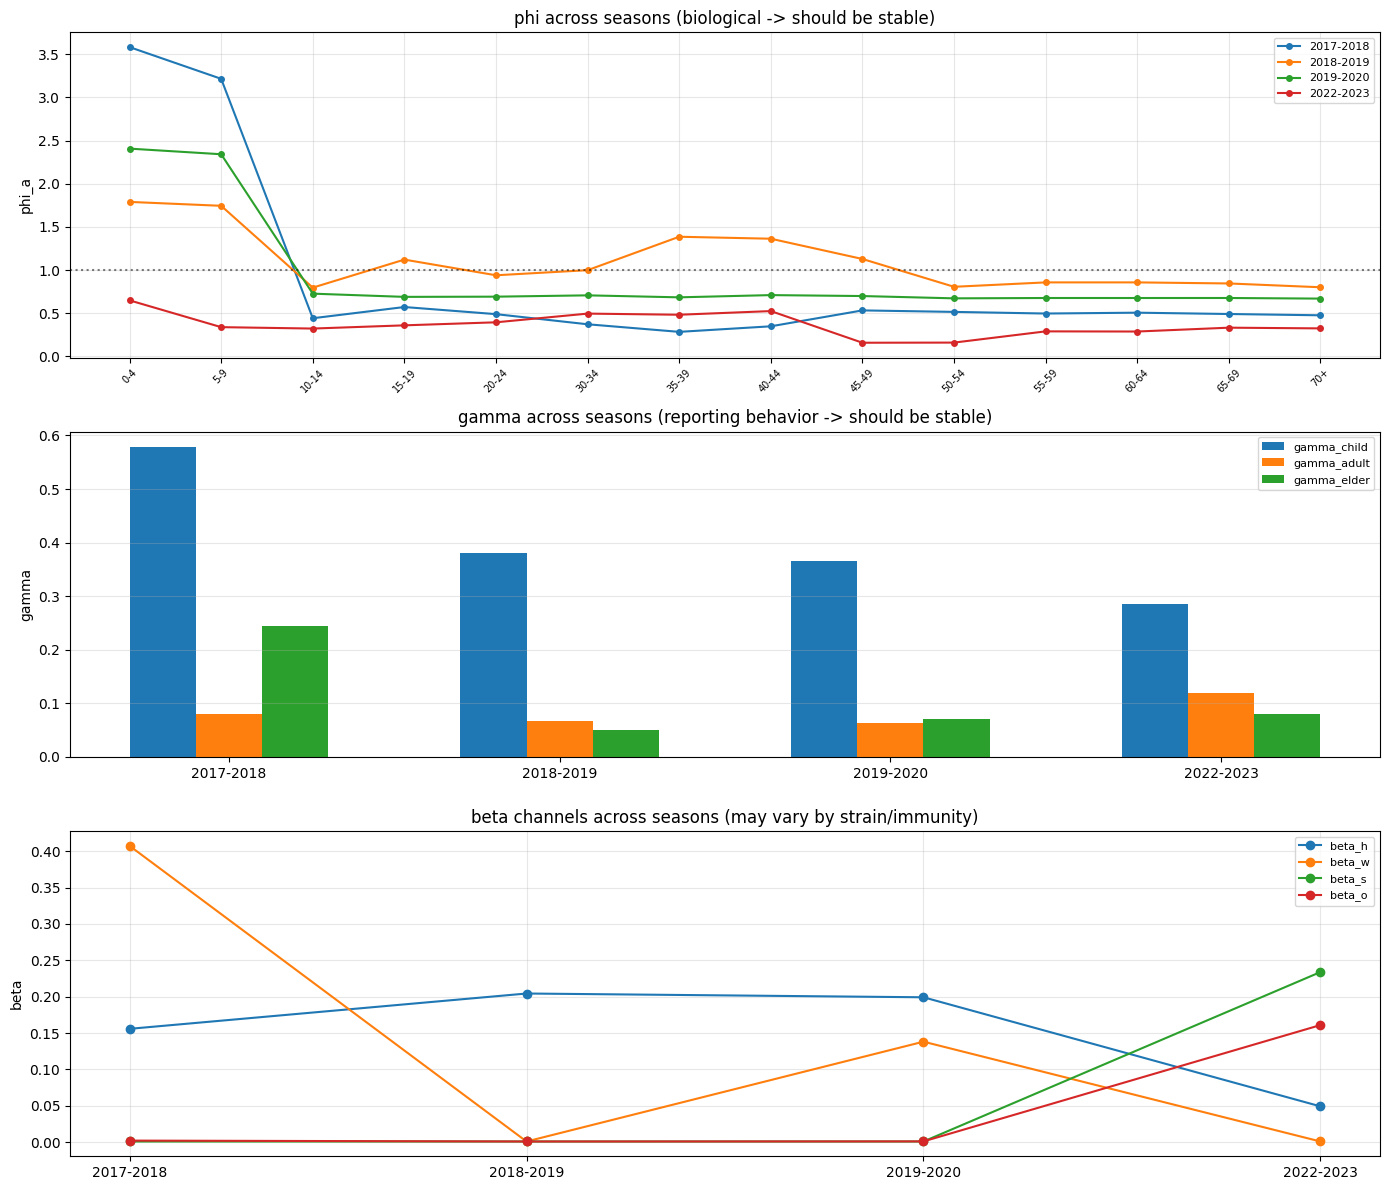

In [8]:
# Cell 8 — Stability plot (phi, gamma, beta across seasons)
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
season_list = list(results.keys())

# Panel 1: phi across seasons
ax = axes[0]
phi_labels = [f"{a*5}-{a*5+4}" if a < 14 else "70+" for a in range(15) if a != 5]
for s, r in results.items():
    phi = np.ones(15)
    idx = 4
    for a in range(15):
        if a == 5: continue
        phi[a] = r.vector[idx]; idx += 1
    ax.plot(range(14), [phi[a] for a in range(15) if a != 5], "o-", label=s, ms=4)
ax.axhline(1.0, color="black", ls=":", alpha=0.5)
ax.set_xticks(range(14))
ax.set_xticklabels(phi_labels, fontsize=7, rotation=45)
ax.set_ylabel("phi_a"); ax.set_title("phi across seasons (biological -> should be stable)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel 2: gamma
ax = axes[1]
x = np.arange(len(season_list))
w = 0.2
for i, (gname, gi) in enumerate([("child", 18), ("adult", 19), ("elder", 20)]):
    vals = [results[s].vector[gi] for s in season_list]
    ax.bar(x + (i-1)*w, vals, width=w, label=f"gamma_{gname}")
ax.set_xticks(x); ax.set_xticklabels(season_list)
ax.set_ylabel("gamma"); ax.set_title("gamma across seasons (reporting behavior -> should be stable)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

# Panel 3: beta channels
ax = axes[2]
for i, bn in enumerate(["beta_h", "beta_w", "beta_s", "beta_o"]):
    vals = [results[s].vector[i] for s in season_list]
    ax.plot(season_list, vals, "o-", label=bn, ms=6)
ax.set_ylabel("beta"); ax.set_title("beta channels across seasons (may vary by strain/immunity)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(OUTDIR / "multi_season_stability.png", dpi=150, bbox_inches="tight")
print("saved multi_season_stability.png"); plt.show()


saved calib_2017-2018_LBFGS_age_gamma.png


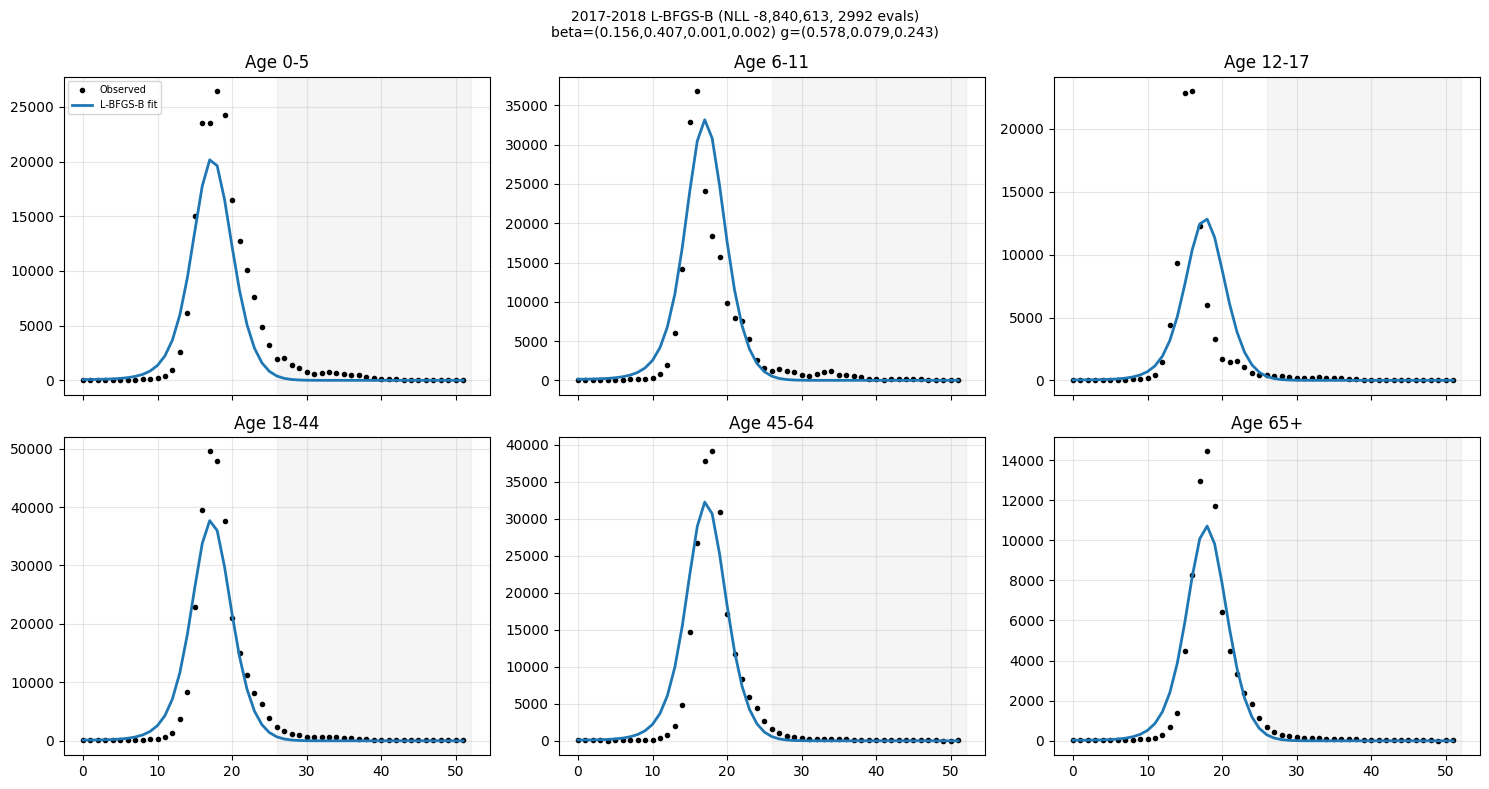

saved calib_2018-2019_LBFGS_age_gamma.png


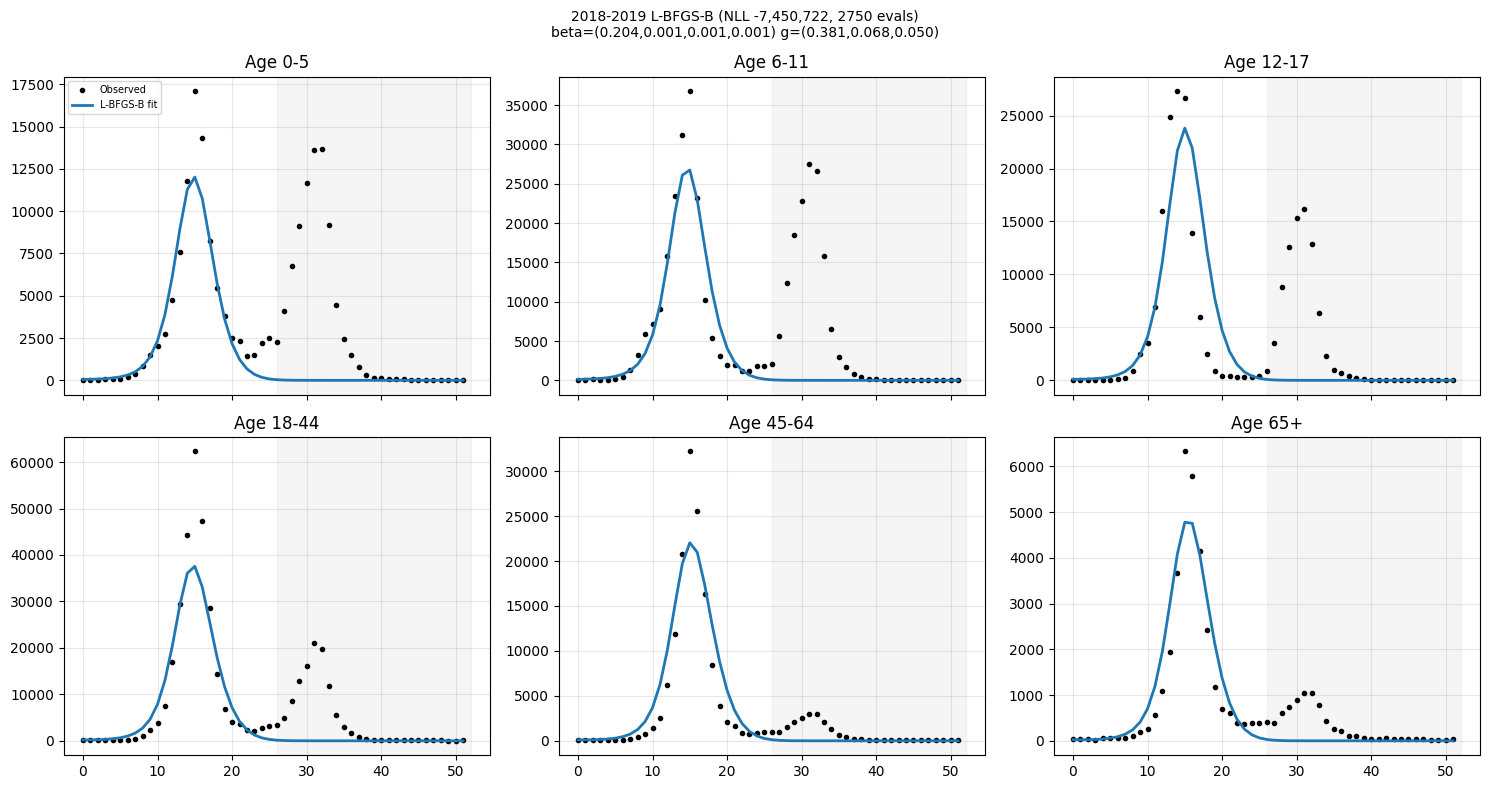

saved calib_2019-2020_LBFGS_age_gamma.png


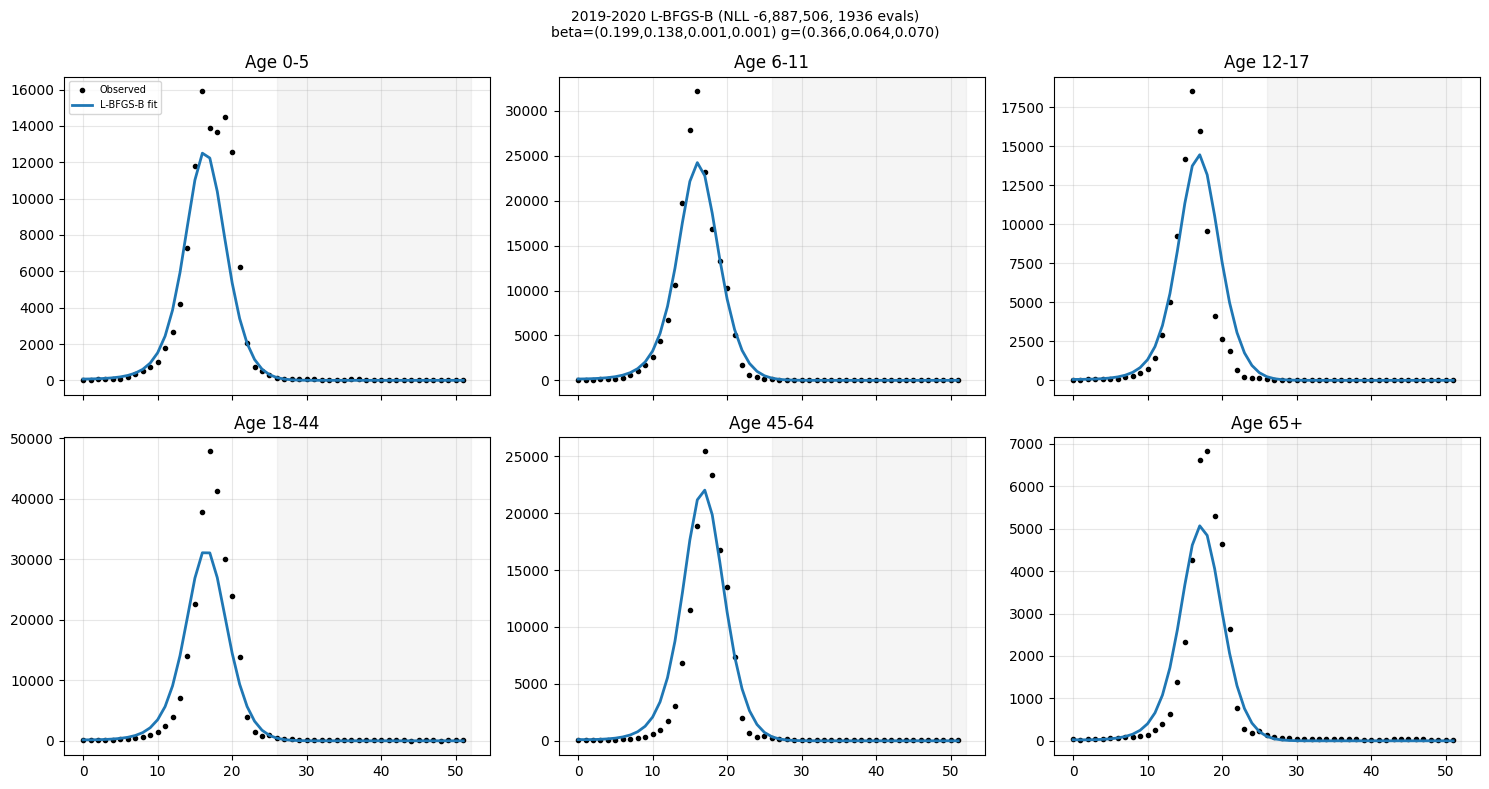

saved calib_2022-2023_LBFGS_age_gamma.png


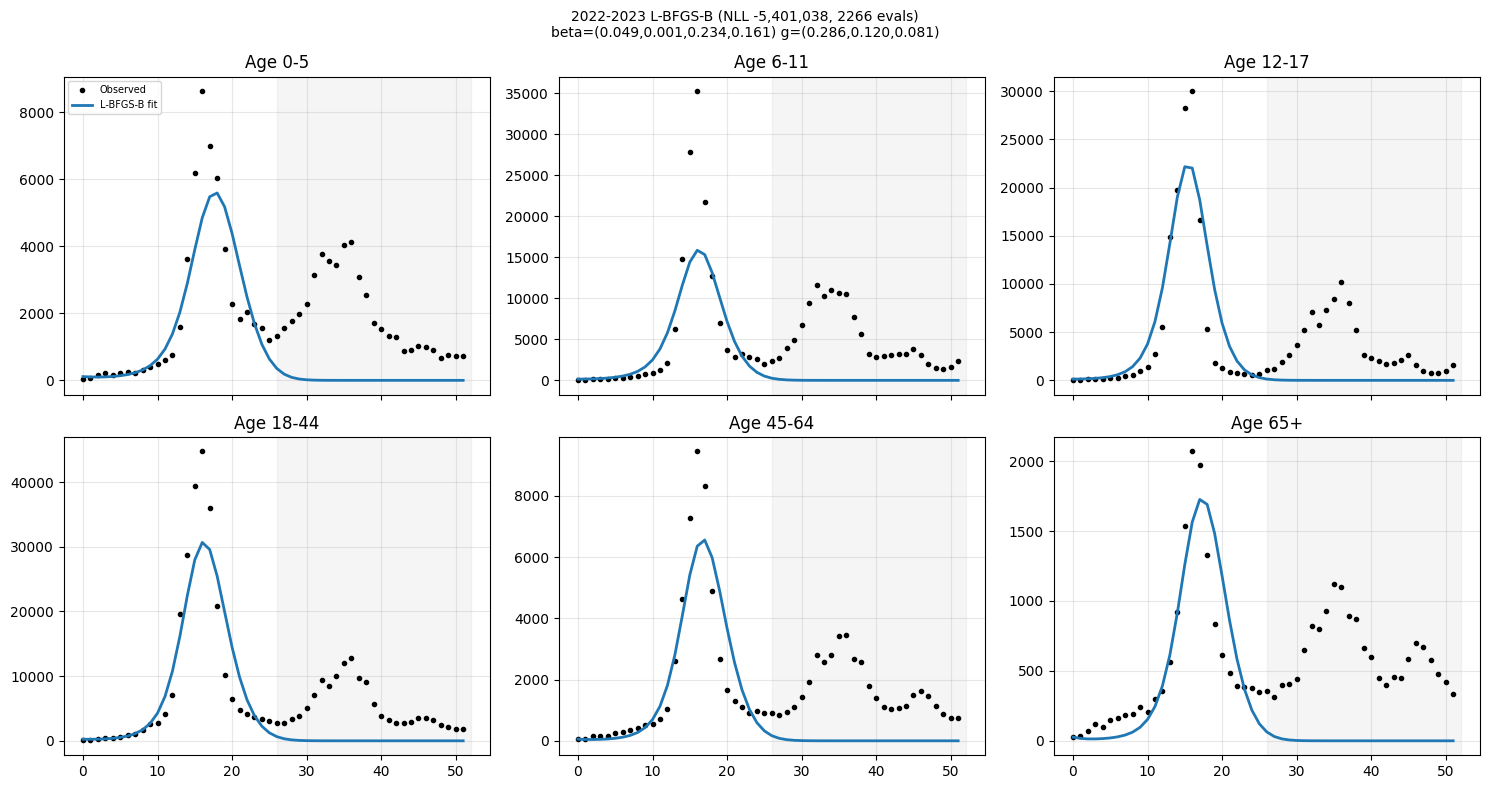

In [9]:
# Cell 9 — Per-season fit plots (6 age panels each)
for s, r in results.items():
    target = load_hira_target_by_age(s, sido_codes=list(SUDOGWON_SIDO_CODES),
                                      first_peak_only=True, first_peak_end_week=26)
    params = ModelParameters().with_calibration(r.calibration)
    seed = estimate_initial_infected_from_hira(
        s, agg_inputs["pop_15"].flatten(), sido_codes=list(SUDOGWON_SIDO_CODES),
        gamma_15_assumed=r.calibration.gamma_15,
    )
    sim = simulate_aggregated(
        params, agg_inputs, seed_total=float(seed.sum()),
        seed_by_age=seed, seed_e_factor=0.5,
        initial_immunity=0.3, initial_vaccinated_fraction=0.0, t_span=(0.0, 364.0),
    )
    daily_inc = sim.daily_new_infection_by_age()
    pred = simulation_to_hira_by_age(daily_inc, r.calibration.gamma_15,
                                      n_weeks=target["n_weeks"])

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
    for ax, ag in zip(axes.flat, HIRA_AGE_GROUPS):
        obs = target["hira_counts"][ag]
        pf = pred[ag]
        ax.plot(target["week_in_season"], obs, "o", color="black", ms=3, label="Observed")
        ax.plot(np.arange(len(pf)), pf, color="#1f77b4", lw=2, label="L-BFGS-B fit")
        ax.axvspan(26, len(pf), alpha=0.08, color="gray")
        ax.set_title(f"Age {ag}"); ax.grid(alpha=0.3)
        if ax is axes.flat[0]: ax.legend(fontsize=7)
    c = r.calibration
    fig.suptitle(f"{s} L-BFGS-B (NLL {r.nll:,.0f}, {r.n_evaluations} evals)\n"
                 f"beta=({c.beta_h:.3f},{c.beta_w:.3f},{c.beta_s:.3f},{c.beta_o:.3f}) "
                 f"g=({c.gamma_child:.3f},{c.gamma_adult:.3f},{c.gamma_elder:.3f})", fontsize=10)
    fig.tight_layout()
    fig.savefig(OUTDIR / f"calib_{s}_LBFGS_age_gamma.png", dpi=150, bbox_inches="tight")
    print(f"saved calib_{s}_LBFGS_age_gamma.png")
    plt.show()


In [10]:
# Cell 10 — Summary + CV analysis
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

# Parameter CV across seasons
param_arrays = {n: [] for n in NAMES}
for s, r in results.items():
    for i, n in enumerate(NAMES):
        param_arrays[n].append(r.vector[i])

print(f"\n--- Parameter CV across {len(results)} seasons ---")
print(f"{'param':>18} {'mean':>8} {'std':>8} {'CV%':>6}")
for n in NAMES:
    vals = np.array(param_arrays[n])
    mean = vals.mean(); std = vals.std()
    cv = std / max(abs(mean), 1e-10) * 100
    if cv > 20:
        flag = " <-- HIGH"
    elif cv > 10:
        flag = " <-- moderate"
    else:
        flag = ""
    print(f"{n:>18} {mean:>8.4f} {std:>8.4f} {cv:>5.1f}%{flag}")

# v4 sanity comparison (2019-2020 only)
if "2019-2020" in results:
    r19 = results["2019-2020"]
    c19 = r19.calibration
    print(f"\n--- v4 NM sanity vs L-BFGS-B (2019-2020) ---")
    print(f"  NLL: (sanity) -> {r19.nll:,.0f}")
    if "2019-2020" in age_bias_all:
        ab = age_bias_all["2019-2020"]
        print(f"  Age bias (peak pred/obs):")
        for ag in HIRA_AGE_GROUPS:
            v4_val = {
                "0-5": 0.37, "6-11": 0.80, "12-17": 1.60,
                "18-44": 1.13, "45-64": 1.60, "65+": 2.43,
            }.get(ag, "?")
            print(f"    {ag:>6}: v4_NM={v4_val}  LBFGS={ab[ag]:.2f}")

print(f"\nTotal parallel wall time: {wall_total:.0f}s ({wall_total/60:.1f} min)")
print(f"Sequential estimate: {sum(o['wall_time'] for o in outputs if o['result']):.0f}s")



SUMMARY

--- Parameter CV across 4 seasons ---
             param     mean      std    CV%
            beta_h   0.1522   0.0623  41.0% <-- HIGH
            beta_w   0.1369   0.1659 121.2% <-- HIGH
            beta_s   0.0592   0.1008 170.3% <-- HIGH
            beta_o   0.0413   0.0691 167.1% <-- HIGH
             phi_0   2.1068   1.0593  50.3% <-- HIGH
             phi_1   1.9100   1.0465  54.8% <-- HIGH
             phi_2   0.5728   0.1958  34.2% <-- HIGH
             phi_3   0.6863   0.2777  40.5% <-- HIGH
             phi_4   0.6297   0.2089  33.2% <-- HIGH
             phi_6   0.6442   0.2375  36.9% <-- HIGH
             phi_7   0.7099   0.4153  58.5% <-- HIGH
             phi_8   0.7373   0.3834  52.0% <-- HIGH
             phi_9   0.6304   0.3481  55.2% <-- HIGH
            phi_10   0.5393   0.2415  44.8% <-- HIGH
            phi_11   0.5808   0.2104  36.2% <-- HIGH
            phi_12   0.5828   0.2101  36.0% <-- HIGH
            phi_13   0.5871   0.1925  32.8% <-- HIGH
       